# Example Seurat to Scanpy Conversion

This notebook shows a simple example of how a Seurat object can easily be converted to AnnData using Seurat's `convert()` functionality and [`anndata2ri`](https://github.com/flying-sheep/anndata2ri), a cool package developed by Phil Angerer.

In [1]:
import scanpy as sc
import numpy as np

import anndata2ri

To make the automatic conversion from R to python work, I activate the converter, and load rpy2.

In [2]:
# Activate the anndata2ri conversion between SingleCellExperiment and AnnData
anndata2ri.activate()

#Loading the rpy2 extension enables cell magic to be used
#This runs R code in jupyter notebook cells
%load_ext rpy2.ipython

sc.settings.verbosity = 3
# sc.logging.print_versions()

I am loading the Seurat clustering tutorial dataset (3k PBMCs from 10x Genomics) to demonstrate the conversion. See the [Seurat tutorial](https://satijalab.org/seurat/v3.0/pbmc3k_tutorial.html) to find instructions on how to download the dataset.

In [20]:
%%R
library(Seurat)
# Load PBMC dataset from Seurat tutorial
#pbmc.data <- Read10X(data.dir = "/Users/nicolebussola/Desktop/Projects/LBP_MountSinai/LBP_brain_blood_pairs/lbp_28samples_seu.RDS")
pbmc <- readRDS("/Users/nicolebussola/Desktop/Projects/LBP_MountSinai/LBP_brain_blood_pairs/lbp_28samples_seu.RDS")

# Initialize the Seurat object with the raw (non-normalized data).
# pbmc <- CreateSeuratObject(counts = pbmc.data, project = "pbmc3k", min.cells = 3, min.features = 200)

pbmc

An object of class Seurat 
49014 features across 107317 samples within 2 assays 
Active assay: SCT (23776 features, 2000 variable features)
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony


The loaded pbmc Seurat object has 13,714 features and 2,700 samples/observations.

Using `as.SingleCellExperiment()` I can use a Seurat function to convert the dataset to a `SingleCellExperiment` object. From there, `anndata2ri` takes care of the rest.

The only thing needed to make the final conversion from R to python here is the addition of `-o pbmc_sce` to the R-magics line. This tells `anndata2ri` to convert the dataset to AnnData, and you can continue working with it from there.

In [47]:
%%R -o pbmc_sce
#convert the Seurat object to a SingleCellExperiment object
pbmc_sce <- as.SingleCellExperiment(pbmc, assay="RNA")

pbmc_sce

class: SingleCellExperiment 
dim: 25238 107317 
metadata(0):
assays(2): X logcounts
rownames(25238): AL627309.1 AL627309.5 ... IGSF5 LINC00323
rowData names(0):
colnames(107317): PT-201-brain-L_AAACCCAAGACTCTAC-1
  PT-201-brain-L_AAACCCAAGGTGCCAA-1 ...
  PT-167-brain-L_TTTGTCATCATATCGG-1 PT-167-brain-L_TTTGTCATCGGTTAAC-1
colData names(9): orig.ident nCount_RNA ... label1 ident
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):


In [49]:
pbmc_sce

AnnData object with n_obs × n_vars = 107317 × 25238
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ribo', 'nCount_SCT', 'nFeature_SCT', 'label1', 'ident'
    obsm: 'X_pca', 'X_umap', 'HARMONY'
    layers: 'logcounts'

As you can see, the number of features and observations is correct. The order has been changed, as AnnData stores single-cell datasets according to machine learning convention, while Seurat follows the R convention. Furthermore, the metadata is all still there, and the `logcounts` assay has been stored as an AnnData layer.

# Show that the conversion worked

From here I just copy some code from the [Seurat](https://satijalab.org/seurat/v3.0/pbmc3k_tutorial.html) and [Scanpy](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) tutorials to show we get the same results.

## Seurat

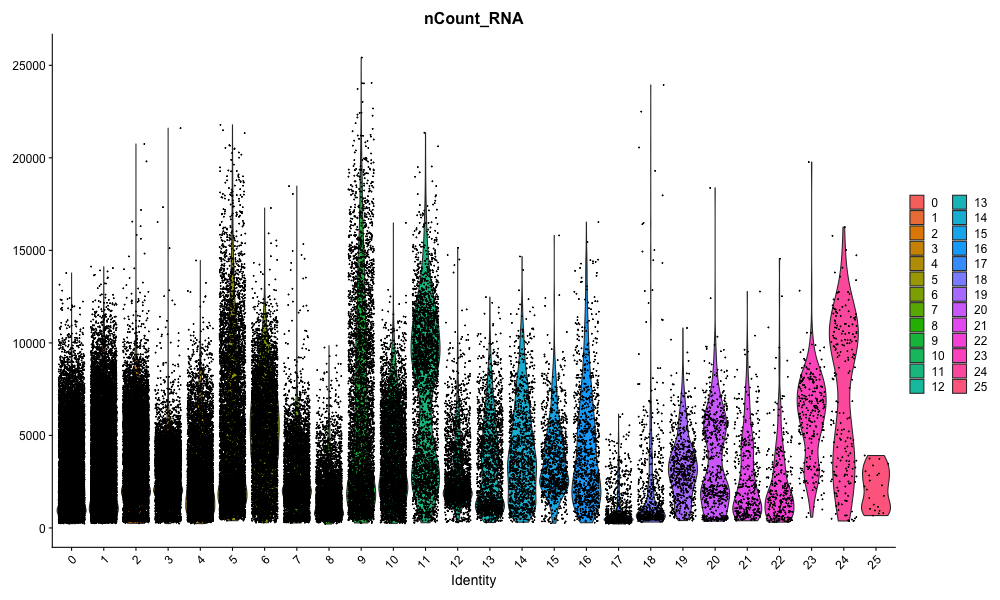

In [59]:
%%R -w 1000 -h 600
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")
VlnPlot(pbmc, features = "percent.mt", ncol = 1)
VlnPlot(pbmc, features = "nCount_RNA", ncol = 1)

# VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

## Scanpy

In [71]:
import pandas as pd
pd.unique(pbmc_sce.obs['ident'])

['10', '0', '1', '4', '14', ..., '15', '12', '24', '23', '25']
Length: 26
Categories (26, object): ['0', '1', '2', '3', ..., '22', '23', '24', '25']

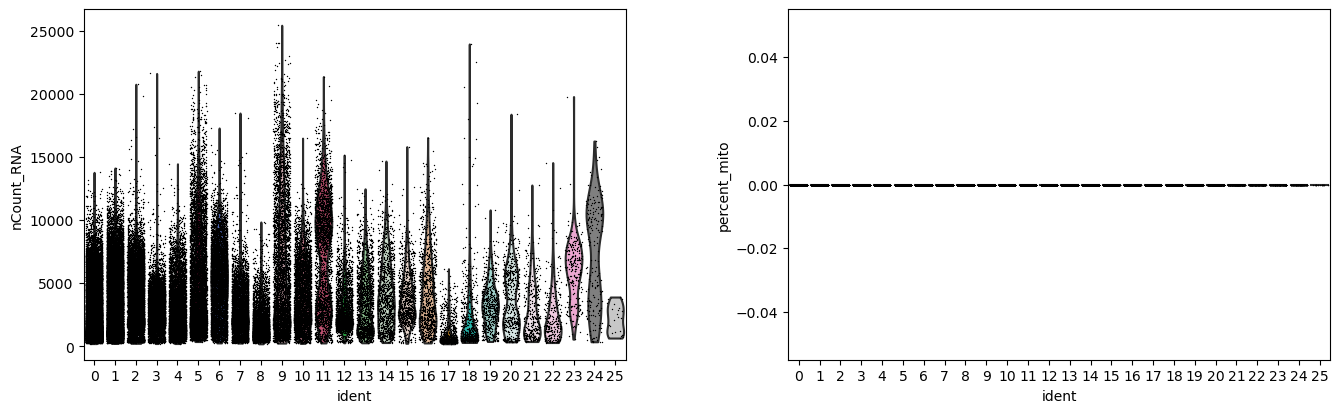

In [72]:
mito_genes = pbmc_sce.var_names.str.startswith('MT-')
pbmc_sce.obs['percent_mito'] = np.sum(pbmc_sce[:, mito_genes].X, axis=1).A1 / np.sum(pbmc_sce.X, axis=1).A1

sc.pl.violin(pbmc_sce, ['nFeature_RNA', 'nCount_RNA', 'percent_mito'], groupby='ident', jitter=0.4, multi_panel=True)